#### mlflow setup and establishing connection to dagshub

In [5]:
import mlflow
import dagshub

mlflow.set_experiment("House prices")
mlflow.set_tracking_uri("https://dagshub.com/gbera23-dev/Machine-Learning.mlflow")

dagshub.init(repo_owner='gbera23-dev', repo_name='Machine-Learning', mlflow=True)

Initialized MLflow to track repo "gbera23-dev/Machine-Learning"

Repository gbera23-dev/Machine-Learning initialized!

#### Importing necessary libraries and loading data into a notebook

In [6]:
import pandas as pd
import numpy as np

train_data_file_path = "house-prices-advanced-regression-techniques/train.csv"
dataset_df = pd.read_csv(train_data_file_path).copy(True)

#### Starting up new preprocessing run

In [7]:
mlflow.start_run(run_name="decision_tree_baseline_model_1")

<ActiveRun: >

#### Exploratory Data Analysis

##### Running a basic check

In [8]:
dataset_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


##### Checking out Categorical and Numerical columns

In [9]:
numerical_part_df = dataset_df.select_dtypes(include=['int64', 'float64'])
categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])

num_numerical = numerical_part_df.columns.size
num_categorical = categorical_part_df.columns.size

print(f"number of numerical columns: {num_numerical}")
print(f"number of categorical columns: {num_categorical}")

mlflow.log_param("num_numerical", num_numerical)
mlflow.log_param("num_categorical", num_categorical)

number of numerical columns: 38
number of categorical columns: 43


43

##### Analyzing numerical columns

In [10]:
numerical_part_df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


##### Analyzing categorical columns

In [11]:
cardinality_dict = {}
for col in categorical_part_df.columns:
    cardinality_dict[col] = categorical_part_df[col].nunique()

cardinality_dict = dict(sorted(cardinality_dict.items(), key=lambda item: item[1], reverse=True))
print(cardinality_dict)

top_5 = dict(list(cardinality_dict.items())[:5])
mlflow.log_param("max cardinality", max(cardinality_dict.values()))
mlflow.log_param("min cardinality", min(cardinality_dict.values()))
mlflow.log_param("5_columns_with_maximal_cardinalities", top_5)

{'Neighborhood': 25, 'Exterior2nd': 16, 'Exterior1st': 15, 'Condition1': 9, 'SaleType': 9, 'Condition2': 8, 'HouseStyle': 8, 'RoofMatl': 8, 'Functional': 7, 'RoofStyle': 6, 'Foundation': 6, 'BsmtFinType1': 6, 'BsmtFinType2': 6, 'Heating': 6, 'GarageType': 6, 'SaleCondition': 6, 'MSZoning': 5, 'LotConfig': 5, 'BldgType': 5, 'ExterCond': 5, 'HeatingQC': 5, 'Electrical': 5, 'FireplaceQu': 5, 'GarageQual': 5, 'GarageCond': 5, 'LotShape': 4, 'LandContour': 4, 'ExterQual': 4, 'BsmtQual': 4, 'BsmtCond': 4, 'BsmtExposure': 4, 'KitchenQual': 4, 'Fence': 4, 'MiscFeature': 4, 'LandSlope': 3, 'MasVnrType': 3, 'GarageFinish': 3, 'PavedDrive': 3, 'PoolQC': 3, 'Street': 2, 'Alley': 2, 'Utilities': 2, 'CentralAir': 2}


{'Neighborhood': 25,
 'Exterior2nd': 16,
 'Exterior1st': 15,
 'Condition1': 9,
 'SaleType': 9}

#### Target Analysis

##### SalePrice distribution

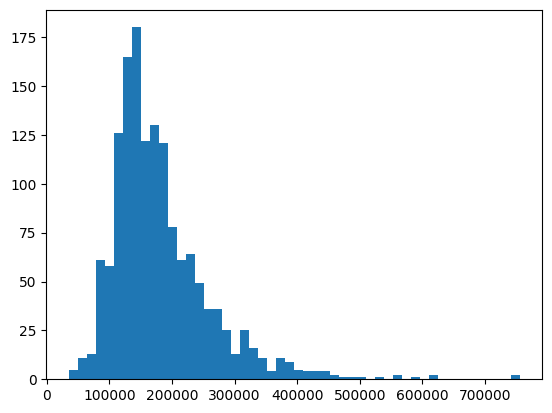

1.8828757597682129


In [12]:
import matplotlib.pyplot as plt

# Decision Tree does not assume normal distribution of the target
# however, we still remove extreme outliers as they represent mansions
# that are structurally different from the typical housing market

salePriceCol = dataset_df['SalePrice']

fig, ax = plt.subplots()
ax.hist(salePriceCol, bins=50)
plt.show()

print(salePriceCol.skew())

mlflow.log_figure(fig, "saleprice_distribution_before_target_manipulation.png")

##### Outlier removal

15


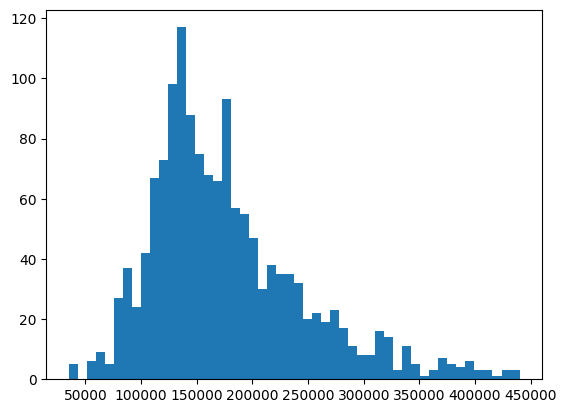

1.0949464064245205


15

In [13]:
# removing houses whose price exceeds the 99th percentile
# these mansion-level prices are rare and confuse the model

upper = dataset_df['SalePrice'].quantile(0.99)

mansion_prices_df = dataset_df[dataset_df['SalePrice'] > upper]

print(len(mansion_prices_df))

dataset_df = dataset_df[dataset_df['SalePrice'] <= upper]

fig, ax = plt.subplots()
ax.hist(dataset_df['SalePrice'], bins=50)
plt.show()

print(dataset_df['SalePrice'].skew())

mlflow.log_param('outlier_method', 'row_removal')
mlflow.log_param('outlier_upper_quantile', 0.99)
mlflow.log_param('num_rows_removed', len(mansion_prices_df))

#### Cleaning

##### Drop useless columns

In [14]:
# drop Id
# drop columns below 40% fill threshold
# note: secondary columns are NOT dropped — correlation will decide

outsider_col_names = ['Id']

average_nonNull_entries = (dataset_df.count().sum() / dataset_df.count().size).__round__()
print(f"average number of entries per column: {average_nonNull_entries}")
print(f"column names that have less than 40% of non - null elements out of total average {[i for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]}")
print(f"number of entries accordingly: {[dataset_df[i].count() for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]}")

mlflow.log_param("avg_non_null", average_nonNull_entries)

[outsider_col_names.append(i) for i in dataset_df.columns if dataset_df[i].count() <= average_nonNull_entries * (40 / 100)]

mlflow.log_param("outsider_columns", outsider_col_names)

for col_name in outsider_col_names:
   if dataset_df.columns.str.contains(col_name).any():
       dataset_df = dataset_df.drop(col_name, axis=1, inplace=False)

mlflow.log_param("dropped columns", outsider_col_names)
mlflow.log_param("number of dropped columns", len(outsider_col_names))

dataset_df.count()
print(outsider_col_names)

average number of entries per column: 1349
column names that have less than 40% of non - null elements out of total average ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
number of entries accordingly: [np.int64(91), np.int64(6), np.int64(279), np.int64(54)]
['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature']


#### Missing value handling

##### Handling null values in numerical data

In [15]:
# universal median fill for all numerical columns with nulls

numerical_part_df = dataset_df.select_dtypes(include=['int64', 'float64'])

num_rows = len(dataset_df)

numeric_columns_with_nan = [col for col in numerical_part_df.columns if dataset_df[col].count() != num_rows]

for col in numeric_columns_with_nan:
    dataset_df[col] = dataset_df[col].fillna(dataset_df[col].median())

mlflow.log_param("numeric_null_method", "universal_median")
mlflow.log_param("numeric_columns_with_nan", numeric_columns_with_nan)

['LotFrontage', 'MasVnrArea', 'GarageYrBlt']

##### Handling null values in categorical data

In [16]:
num_rows = len(dataset_df)

categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])

categorical_columns_with_Nan_entries = []

for col in categorical_part_df.columns:
    if dataset_df[col].count() != num_rows:
        categorical_columns_with_Nan_entries.append(col)

print(categorical_columns_with_Nan_entries)

mlflow.log_param("categorical_columns_with_Nan_entries", categorical_columns_with_Nan_entries)

for col in categorical_columns_with_Nan_entries:
    dataset_df[col] = dataset_df[col].fillna("None")

dataset_df.head(5)

mlflow.log_param("categorical_data_null_replacements", ["just string : None"])

['MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']


['just string : None']

#### Feature Engineering

##### pre - FE analysis

In [17]:
area_cols = [col for col in dataset_df.columns if 'SF' in col or 'Area' in col]
print("Area columns:", area_cols)

time_cols = [col for col in dataset_df.columns if 'Yr' in col or 'Year' in col or 'Mo' in col]
print("Time columns:", time_cols)

bath_cols = [col for col in dataset_df.columns if 'Bath' in col or 'Bsmt' in col]
print("Bath columns:", bath_cols)

Area columns: ['LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'PoolArea']
Time columns: ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold']
Bath columns: ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath']


##### Creating new features

In [18]:
dataset_df['TotalSF'] = dataset_df['TotalBsmtSF'] + dataset_df['1stFlrSF'] + dataset_df['2ndFlrSF']
dataset_df['HouseAge'] = dataset_df['YrSold'] - dataset_df['YearBuilt']
dataset_df['RemodAge'] = dataset_df['YrSold'] - dataset_df['YearRemodAdd']
dataset_df['TotalBath'] = dataset_df['FullBath'] + 0.5 * dataset_df['HalfBath'] + dataset_df['BsmtFullBath'] + 0.5 * dataset_df['BsmtHalfBath']
dataset_df['IsRemodeled'] = (dataset_df['YearRemodAdd'] != dataset_df['YearBuilt']).astype(int)

engineered_features = ['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'IsRemodeled']
mlflow.log_param('engineered_features', engineered_features)

['TotalSF', 'HouseAge', 'RemodAge', 'TotalBath', 'IsRemodeled']

#### Turning categorical variables to numeric

##### Pre-encoding analysis

In [19]:
categorical_part_df = dataset_df.select_dtypes(exclude=['int64', 'float64'])
cardinality_dict = {}
for col in categorical_part_df.columns:
    cardinality_dict[col] = categorical_part_df[col].nunique()
print(cardinality_dict)

{'MSZoning': 5, 'Street': 2, 'LotShape': 4, 'LandContour': 4, 'Utilities': 2, 'LotConfig': 5, 'LandSlope': 3, 'Neighborhood': 25, 'Condition1': 9, 'Condition2': 8, 'BldgType': 5, 'HouseStyle': 8, 'RoofStyle': 6, 'RoofMatl': 8, 'Exterior1st': 15, 'Exterior2nd': 16, 'MasVnrType': 4, 'ExterQual': 4, 'ExterCond': 5, 'Foundation': 6, 'BsmtQual': 5, 'BsmtCond': 5, 'BsmtExposure': 5, 'BsmtFinType1': 7, 'BsmtFinType2': 7, 'Heating': 6, 'HeatingQC': 5, 'CentralAir': 2, 'Electrical': 6, 'KitchenQual': 4, 'Functional': 7, 'FireplaceQu': 6, 'GarageType': 7, 'GarageFinish': 4, 'GarageQual': 6, 'GarageCond': 6, 'PavedDrive': 3, 'SaleType': 9, 'SaleCondition': 6}


##### one hot encoding

In [20]:
dataset_df = pd.get_dummies(dataset_df, dtype=int, drop_first=True)
dataset_df.info()
mlflow.log_param("number of columns after OHE", dataset_df.columns.size)

<class 'pandas.core.frame.DataFrame'>
Index: 1445 entries, 0 to 1459
Columns: 253 entries, MSSubClass to SaleCondition_Partial
dtypes: float64(4), int64(249)
memory usage: 2.8 MB


253

#### Feature selection

##### Splitting data to train and test sets

In [21]:
from sklearn.model_selection import train_test_split

X = dataset_df.drop(columns=['SalePrice'])
y = dataset_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

mlflow.log_param("train to test proportion", "85% to 15%")

'85% to 15%'

##### Correlation checks

###### Pre-correlation analysis

In [22]:
columns_with_low_std = [col for col in X_train.columns if X_train[col].std() <= 0.01]
print(columns_with_low_std)

for col in columns_with_low_std:
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

mlflow.log_param("columns_with_low_std_in_X_train", columns_with_low_std)

['Neighborhood_Blueste', 'Exterior2nd_Other', 'Functional_Sev']


['Neighborhood_Blueste', 'Exterior2nd_Other', 'Functional_Sev']

###### Checking correlations inbetween columns

In [23]:
correlation_threshold = 0.85

columns_with_high_correlation = []

abs_corr_between_cols = X_train.corr().abs()

i = 0
j = 0
for Xcol in X_train.columns:
    for Ycol in X_train.columns:
        if i < j and abs_corr_between_cols[Xcol][Ycol] > correlation_threshold:
            if Ycol not in columns_with_high_correlation:
                columns_with_high_correlation.append(Ycol)
        j = j + 1
    j = 0
    i = i + 1

print(columns_with_high_correlation)
print(f"number of columns with absolute correlation more than {correlation_threshold} is {len(columns_with_high_correlation)}")
print(f"total columns in X_train is {len(X_train.columns)}")

mlflow.log_param("correlation_threshold_between_columns", correlation_threshold)
mlflow.log_param("columns_with_high_correlation_between_them", columns_with_high_correlation)

for col in columns_with_high_correlation:
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

print(len(X_train.columns))

['HouseAge', 'RemodAge', 'TotalSF', 'FireplaceQu_None', 'GarageArea', 'Neighborhood_Somerst', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'Exterior2nd_CmentBd', 'Exterior2nd_HdBoard', 'Exterior2nd_MetalSd', 'Exterior2nd_VinylSd', 'Exterior2nd_Wd Sdng', 'ExterQual_TA', 'ExterCond_TA', 'BsmtCond_None', 'BsmtExposure_None', 'BsmtFinType1_None', 'BsmtFinType2_None', 'GarageFinish_None', 'GarageQual_None', 'GarageCond_None', 'SaleCondition_Partial']
number of columns with absolute correlation more than 0.85 is 23
total columns in X_train is 249
226


###### Checking correlations with target

In [24]:
correlation_threshold = 0.1

corr_with_target = X_train.corrwith(y_train).abs().sort_values(ascending=False)

columns_with_low_correlation = [col for col in X_train.columns if corr_with_target[col] <= correlation_threshold]

print(columns_with_low_correlation)
print(f"length of the columns_with_low_correlation is {len(columns_with_low_correlation)}")

mlflow.log_param("correlation_threshold_to_target", correlation_threshold)
mlflow.log_param("number_of_columns_with_low_corr_with_target", len(columns_with_low_correlation))

for col in columns_with_low_correlation:
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)

print(corr_with_target.head(10))

mlflow.log_param("top_10_columns_with_highest_correlation_to_target", corr_with_target.head(10))

len(X_train.columns)

['MSSubClass', 'OverallCond', 'BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold', 'IsRemodeled', 'MSZoning_RH', 'Street_Pave', 'LotShape_IR3', 'LandContour_Low', 'LandContour_Lvl', 'Utilities_NoSeWa', 'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod', 'LandSlope_Sev', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Gilbert', 'Neighborhood_Mitchel', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_SWISU', 'Neighborhood_SawyerW', 'Neighborhood_Veenker', 'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe', 'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn', 'Condition2_Feedr', 'Condition2_Norm', 'Condition2_PosA', 'Condition2_PosN', 'Condition2_RRAe', 'Condition2_RRAn', 'Condition2_RRNn', 'BldgType_TwnhsE', 'HouseStyle_1.5Unf', 'HouseStyle_1Story', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'RoofStyle_Gambrel', 'RoofStyle_Mansard', 

106

#### Logging X_train structure to reindex test data in inference

In [25]:
import json
with open('train_columns_decision_tree.json', 'w') as f:
    json.dump(list(X_train.columns), f)

#### Training — Decision Tree

##### Training with Cross Validation

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np

model = DecisionTreeRegressor(random_state=42)

mlflow.log_param("model", "DecisionTreeRegressor")

scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

rmse_scores = -scores
mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

print(f"RMSE per fold: {rmse_scores}")
print(f"Mean RMSE: {mean_rmse}")
print(f"Std RMSE: {std_rmse}")

mlflow.log_metric("mean_cv_rmse", mean_rmse)
mlflow.log_metric("std_cv_rmse", std_rmse)

RMSE per fold: [27684.50296644 37777.51774498 32305.22830549 34927.34792096
 38858.71973474]
Mean RMSE: 34310.663334520716
Std RMSE: 4025.2196780107156


##### Evaluating and logging metrics

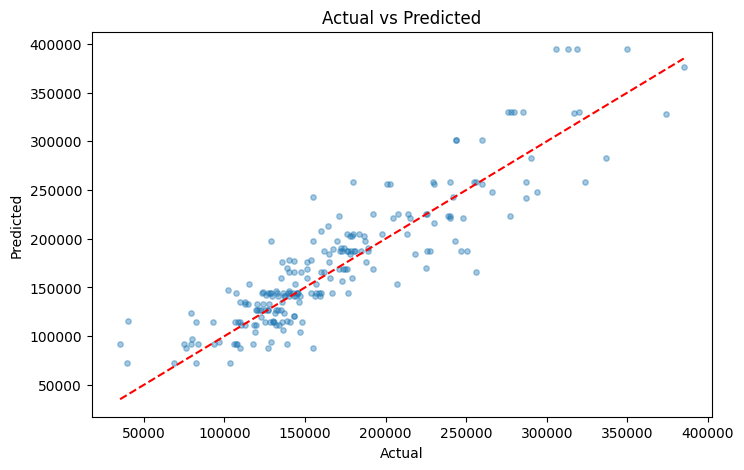

In [27]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

mlflow.log_metric("test_rmse", test_rmse)
mlflow.log_metric("test_mae", test_mae)
mlflow.log_metric("test_r2", test_r2)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_test, y_pred, alpha=0.4, s=15)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title('Actual vs Predicted')

mlflow.log_figure(fig, "actual_vs_predicted.png")

##### Logging model

In [28]:
mlflow.sklearn.log_model(model, "decision_tree_baseline")

2026/04/10 01:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/10 01:16:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


#### Check underfitting, overfitting

In [29]:
train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_r2 = r2_score(y_train, train_pred)

print(f"Train RMSE: {train_rmse}")
print(f"Test RMSE: {test_rmse}")
print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")

# for a default Decision Tree, train RMSE will be 0 and train R2 will be 1.0
# this is expected — the tree memorizes every training sample
print(f"Difference: {test_rmse - train_rmse}")

mlflow.log_metric("train_rmse", train_rmse)
mlflow.log_metric("train_r2", train_r2)

Train RMSE: 22723.306451138695
Test RMSE: 29788.900153235703
Train R2: 0.8963842937911564
Test R2: 0.7761989091583714
Difference: 7065.593702097009


#### Ending the run

In [30]:
mlflow.end_run()

🏃 View run decision_tree_optimized_model_1 at: https://dagshub.com/gbera23-dev/Machine-Learning.mlflow/#/experiments/2/runs/712420bce1e34df59c6680984aeacd29
🧪 View experiment at: https://dagshub.com/gbera23-dev/Machine-Learning.mlflow/#/experiments/2


In [1]:
from mlflow.tracking import MlflowClient
from mlflow.tracking import MlflowClient

client = MlflowClient()
run_id = mlflow.last_active_run().info.run_id

client.create_model_version(
    name="house_prices_decision_tree_baseline",
    source=f"runs:/{run_id}/decision_tree_baseline",
    run_id=run_id
)

/home/giga/FREEUNI/semester_6/ML/Machine-Learning/Assignment1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'mlflow' is not defined